## Cleaning Data -> Missing Data

In [42]:
import pandas as pd
import numpy as np
from scipy import stats
from utils.utils import setup_project_root

setup_project_root()

WindowsPath('C:/Users/zak/Projects/PyCharmProjects/data-science')

In [43]:
diabetes = pd.read_csv(r'data/diabetes.csv')

In [44]:
diabetes['Diastolic_BP'].corr(diabetes['Glucose'])

np.float64(0.2231917782495421)

In [45]:
stats.pearsonr(diabetes['Diastolic_BP'], diabetes['Glucose'])

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

## Dealing with missing data

- MAR: Missing at Random - the good ones.
    - Not coming from a systematic error
    - Low in proportion (5% - 10%)
    - Lack of/no apparent correlation to variables in terms of missing data
    - Actions available after identification = Imputation


- MNAR: Missing not at random - the bad ones.
    - Systematic error involved
    - High proportion > 40%
    - Strong evidence of correlation
    - Actions available after identification = Imputation


- MCAR: Missing Completely at Random
    - A low version of MAR


In [46]:
diabetes.isnull().sum()
diabetes.isnull().mean()

Pregnant             0.000000
Glucose              0.006510
Diastolic_BP         0.045573
Skin_Fold            0.295573
Serum_Insulin        0.486979
BMI                  0.014323
Diabetes_Pedigree    0.000000
Age                  0.000000
Class                0.000000
dtype: float64

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='0', ylabel='index'>

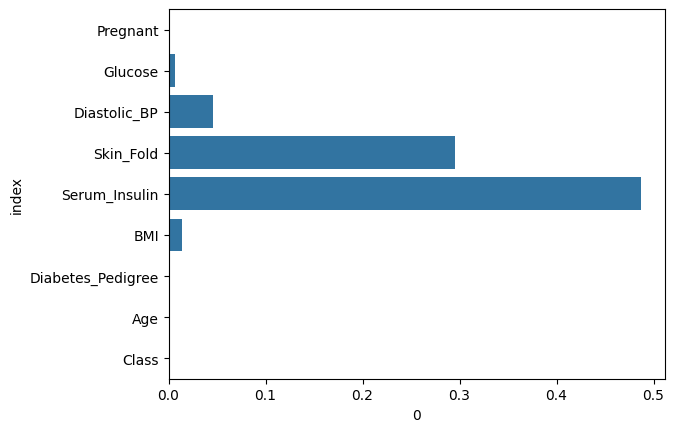

In [48]:
missing_proportions = diabetes.isnull().mean().reset_index()
sns.barplot(missing_proportions, y='index', x=0)

In [49]:
import missingno as msno

<Axes: >

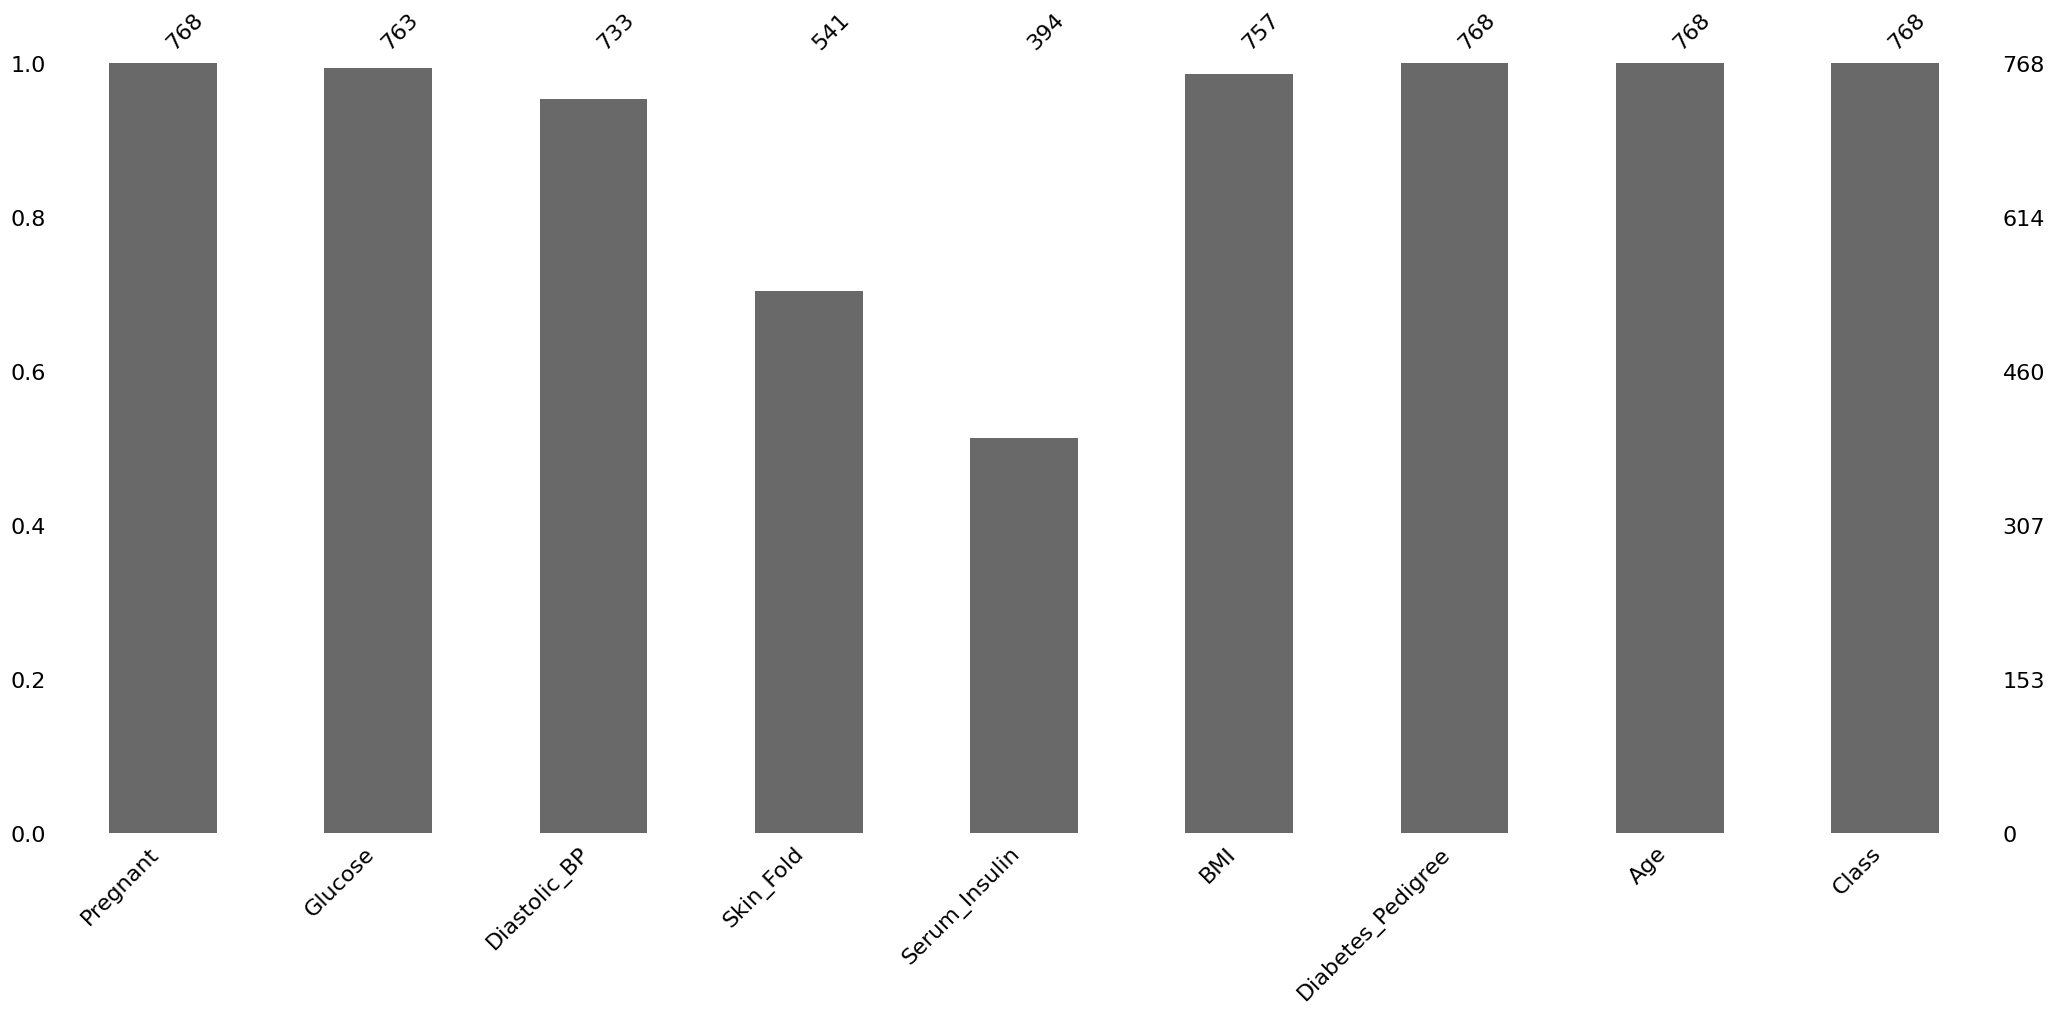

In [50]:
msno.bar(diabetes)

<Axes: >

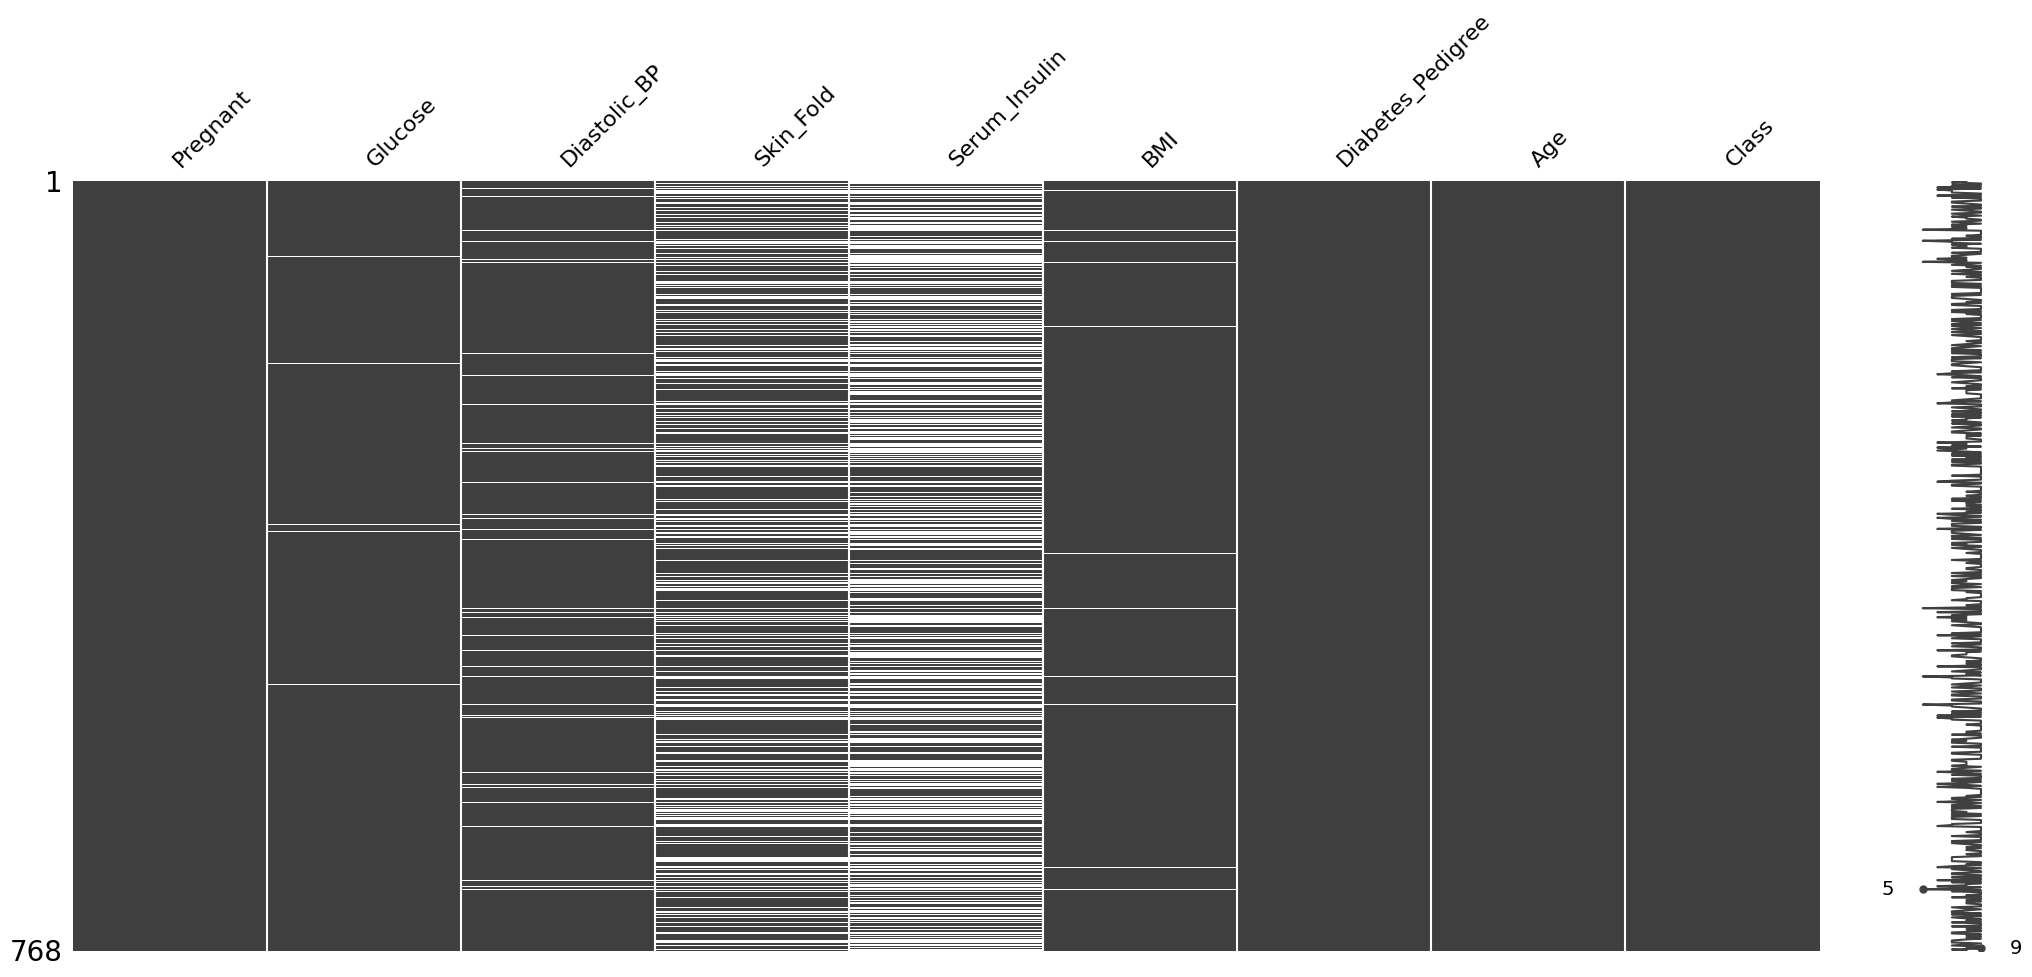

In [51]:
msno.matrix(diabetes)

<Axes: >

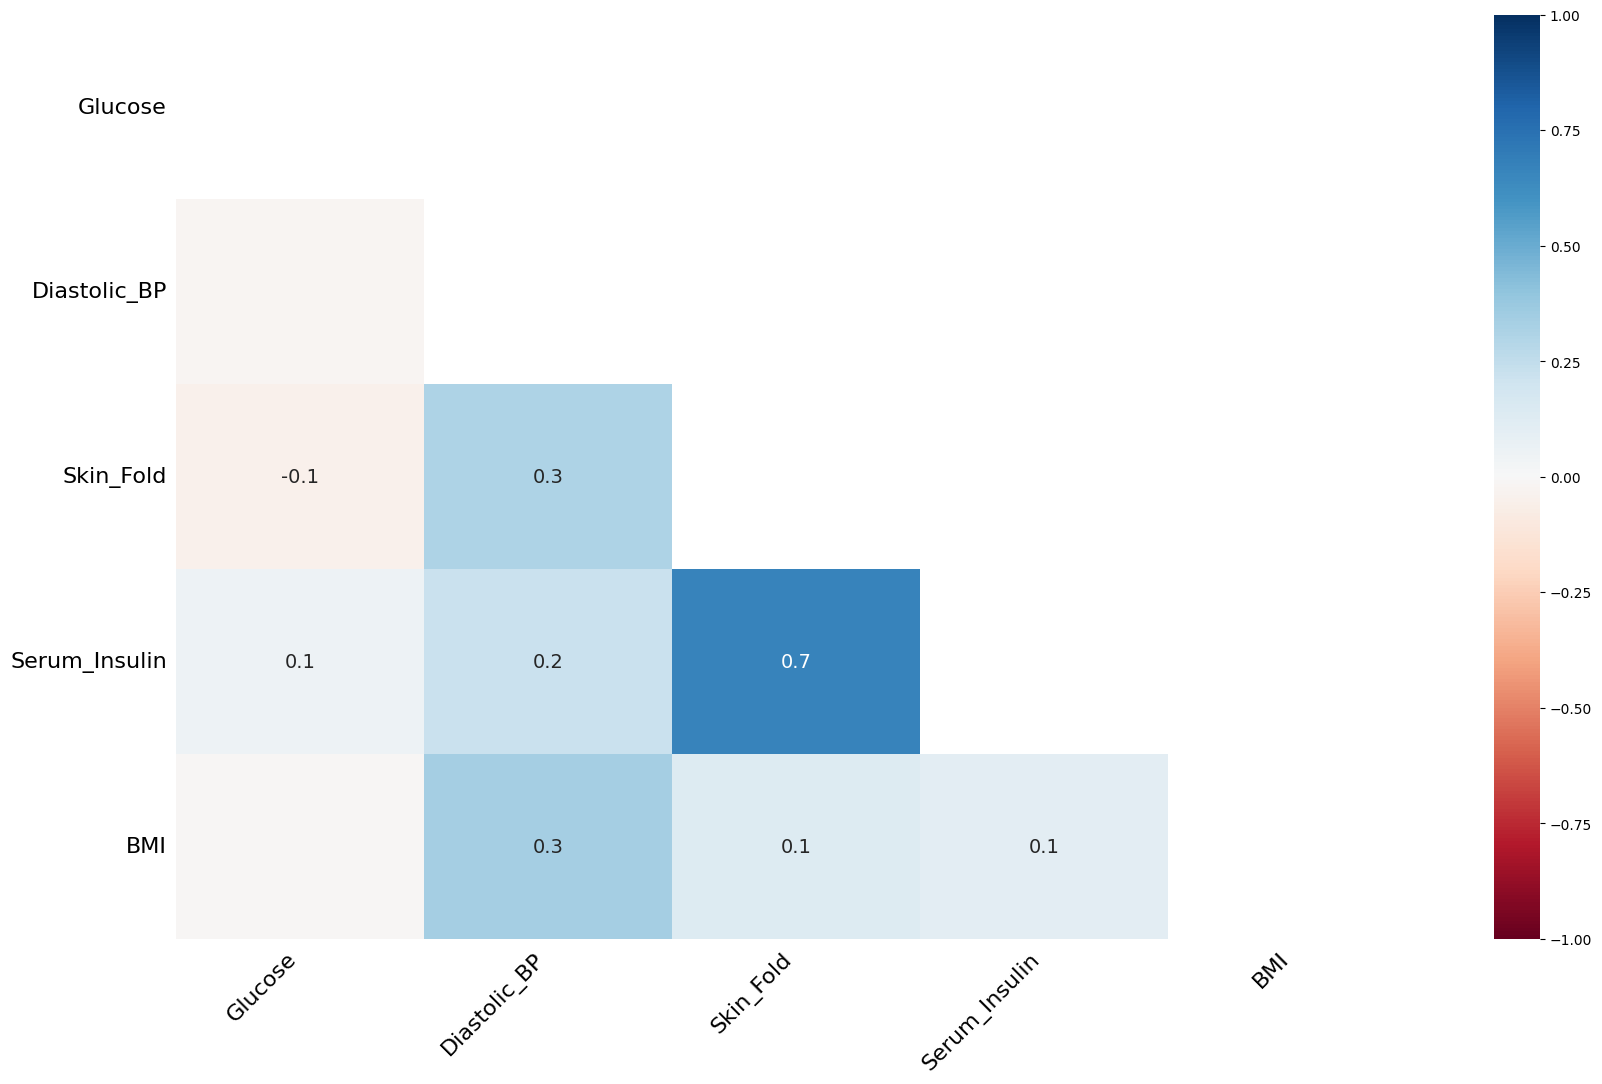

In [52]:
msno.heatmap(diabetes)

In [53]:
matrix = np.array([[1, 0, 1],
                   [0, 1, 0],
                   [3, 2, 3]])
matrix

array([[1, 0, 1],
       [0, 1, 0],
       [3, 2, 3]])

In [54]:
import pandas as pd
from scipy import stats
import os

os.getcwd()

'C:\\Users\\zak\\Projects\\PyCharmProjects\\data-science'

In [55]:
air_quality = pd.read_csv(r'data/air-quality.csv')

In [56]:
air_quality

,Date,Ozone,Solar,Wind,Temp
0,1976-05-01,41.0,190.0,7.4,67
1,1976-05-02,36.0,118.0,8.0,72
2,1976-05-03,12.0,149.0,12.6,74
3,1976-05-04,18.0,313.0,11.5,62
4,1976-05-05,NaN,NaN,14.3,56
...,...,...,...,...,...
148,1976-09-26,30.0,193.0,6.9,70
149,1976-09-27,NaN,145.0,13.2,77
150,1976-09-28,14.0,191.0,14.3,75
151,1976-09-29,18.0,131.0,8.0,76


In [57]:
air_quality['Ozone'].corr(air_quality['Wind'])

np.float64(-0.6015465298889496)

In [58]:
stats.pearsonr(air_quality['Ozone'], air_quality['Wind'])

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [59]:
air_quality.isnull().sum()
air_quality.isnull().mean()

Date     0.000000
Ozone    0.241830
Solar    0.045752
Wind     0.000000
Temp     0.000000
dtype: float64

In [60]:
import seaborn as sns

<Axes: xlabel='0', ylabel='index'>

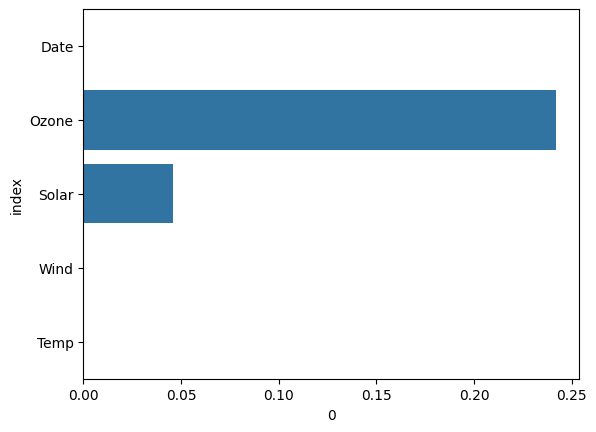

In [61]:
missing_proportions = air_quality.isnull().mean().reset_index()
sns.barplot(missing_proportions, y='index', x=0)

Approx one quarter of Ozone data is missing.

Is the missing data just random?

In [62]:
import missingno as msno

<Axes: >

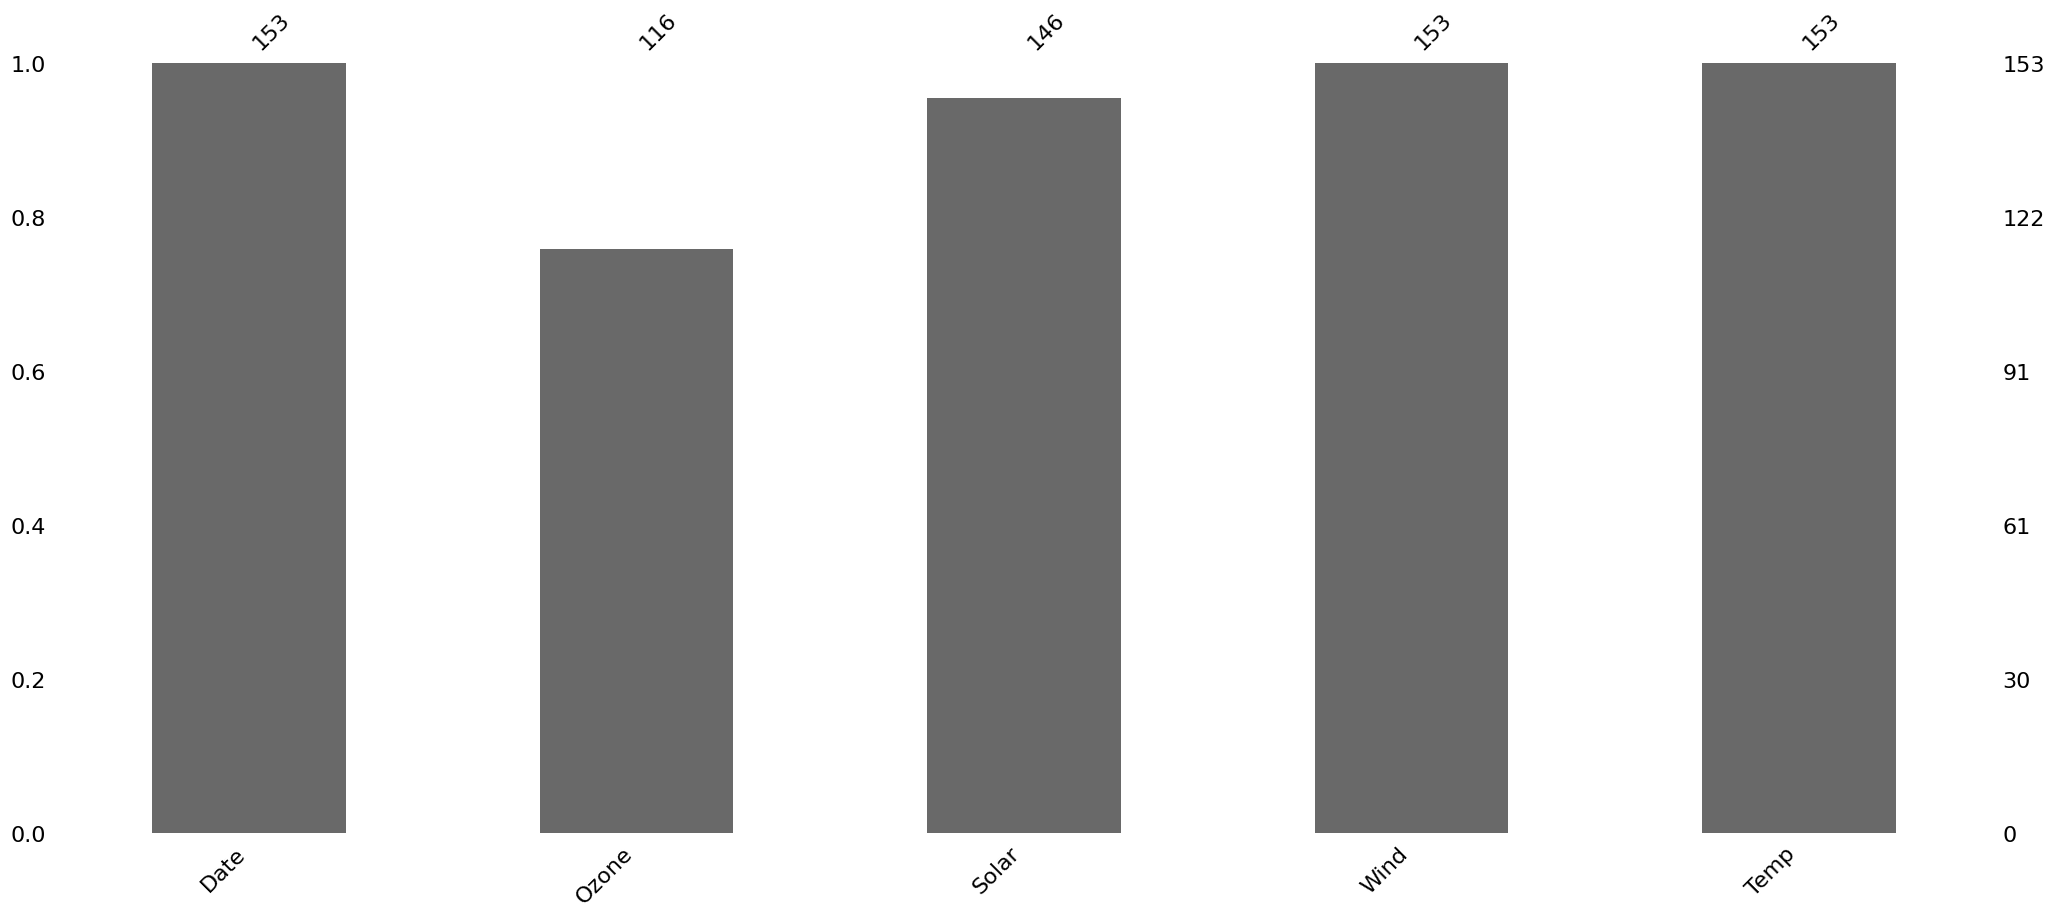

In [63]:
msno.bar(air_quality)

<Axes: >

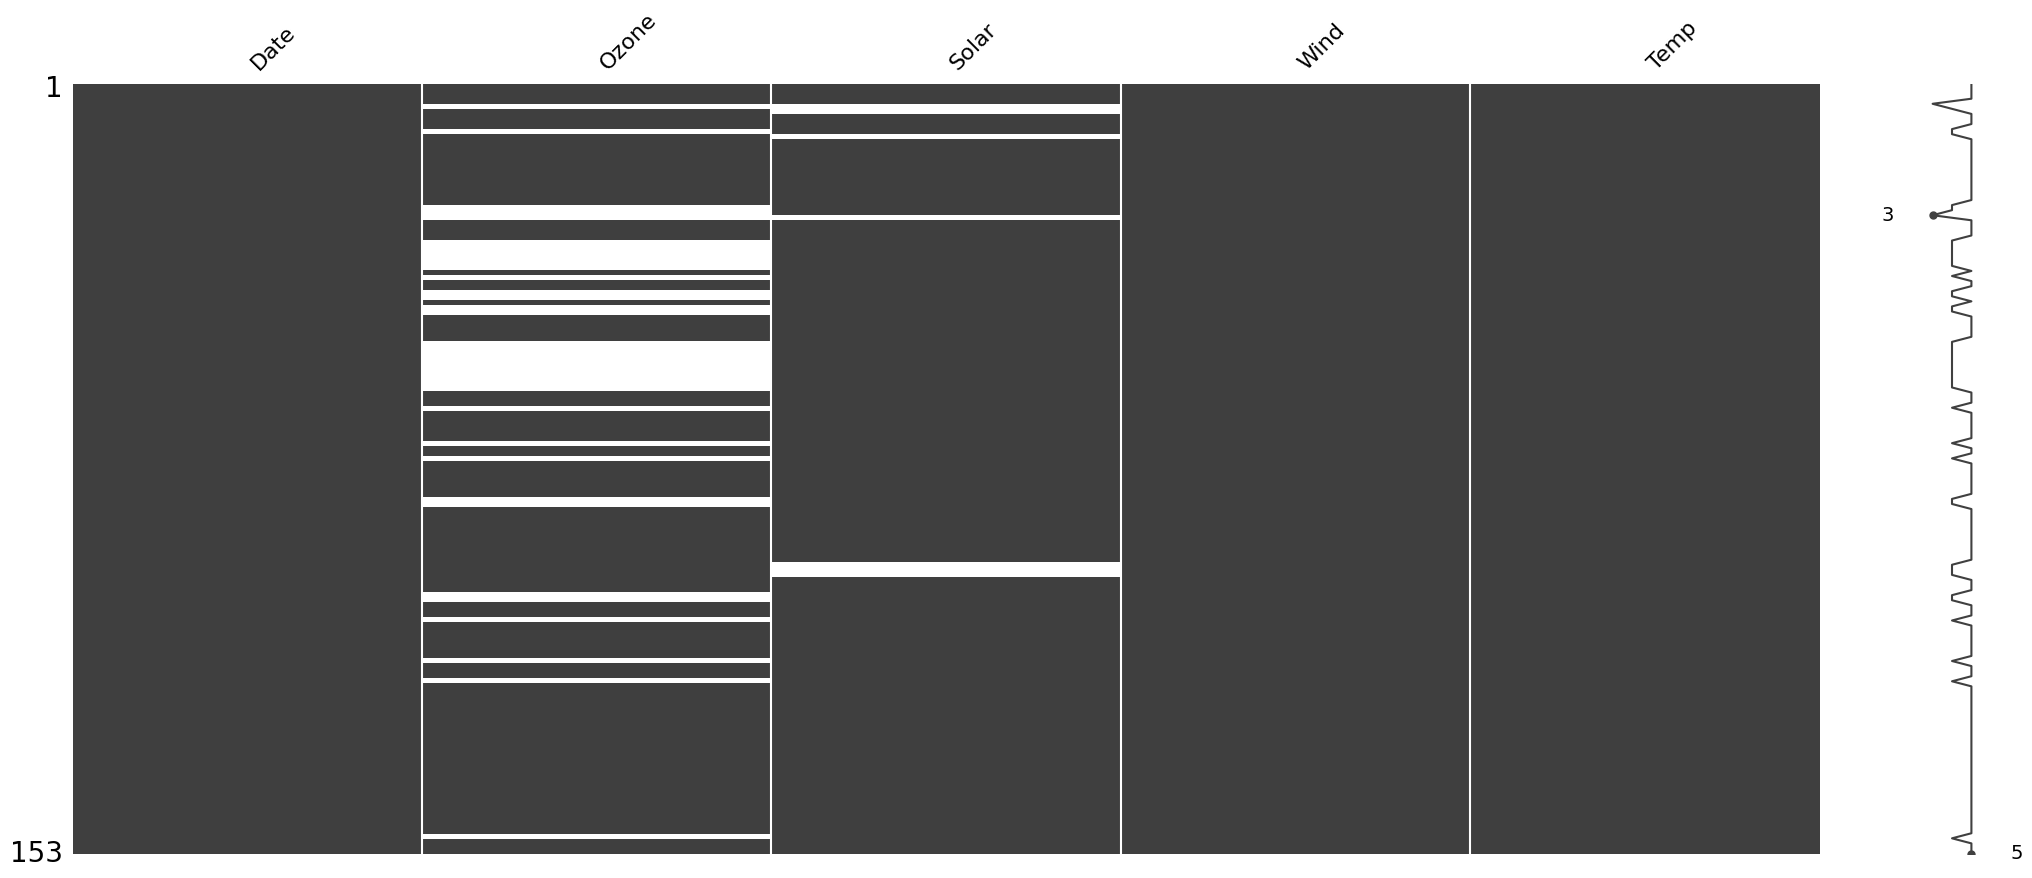

In [64]:
msno.matrix(air_quality)

<llm-snippet-file>01_cleaning_data.ipynb</llm-snippet-file>


<Axes: >

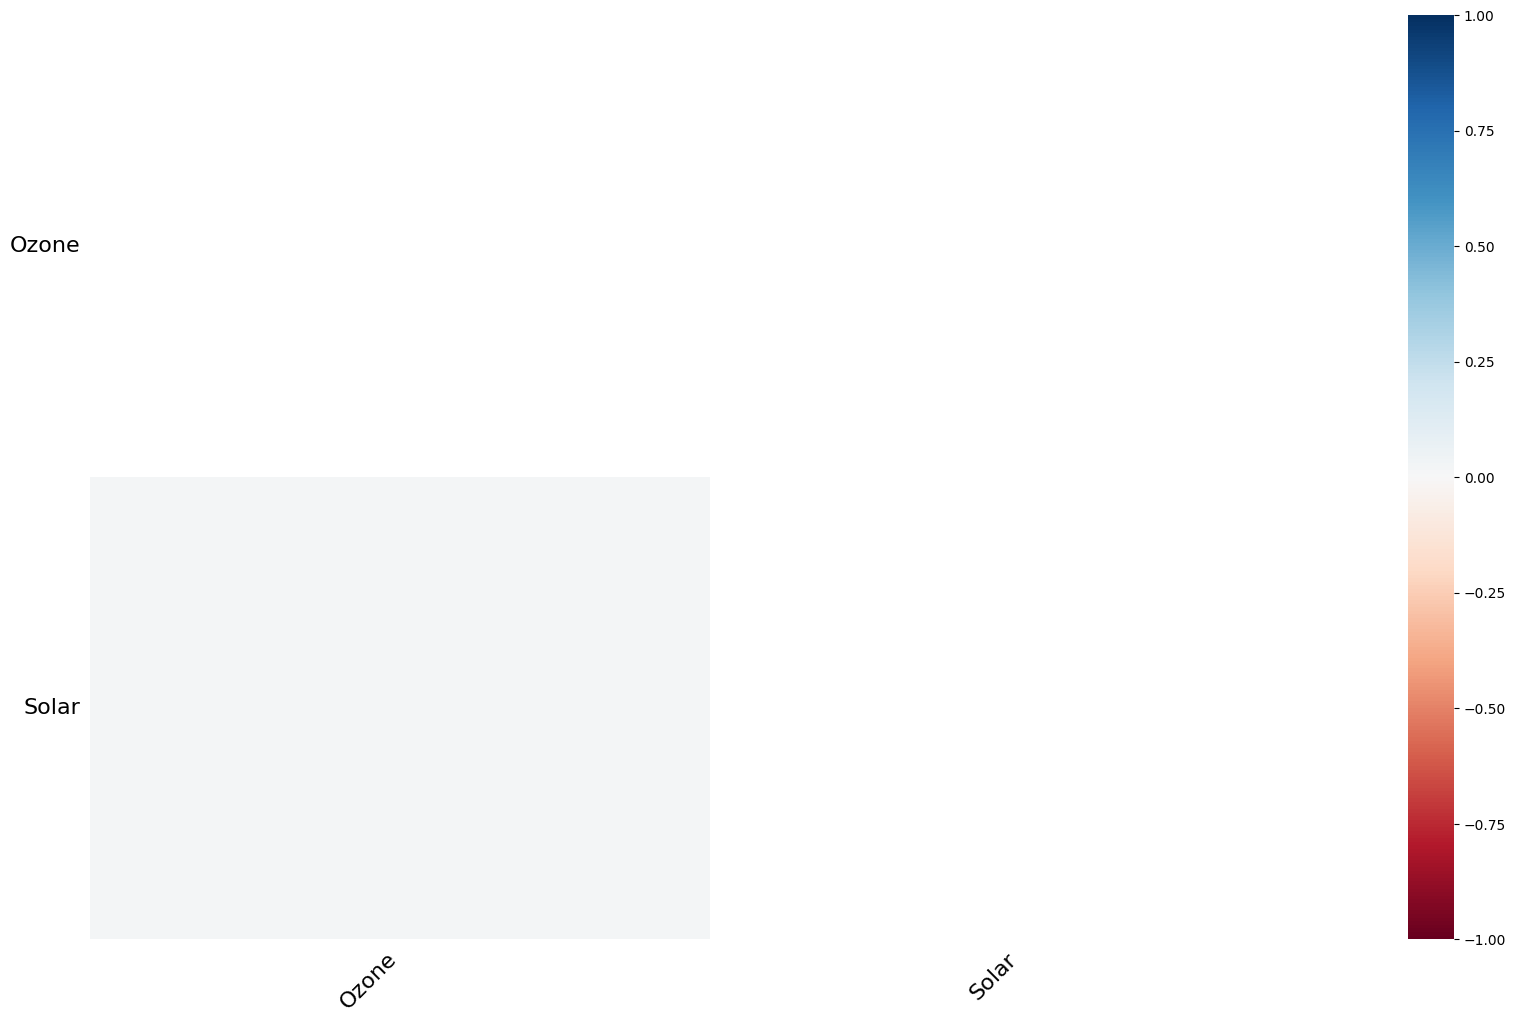

In [65]:
msno.heatmap(air_quality)

Plot Ozone over time with improved x-axis formatting and broken lines at missing values

In [66]:
air_quality['Date'] = pd.to_datetime(air_quality['Date'])

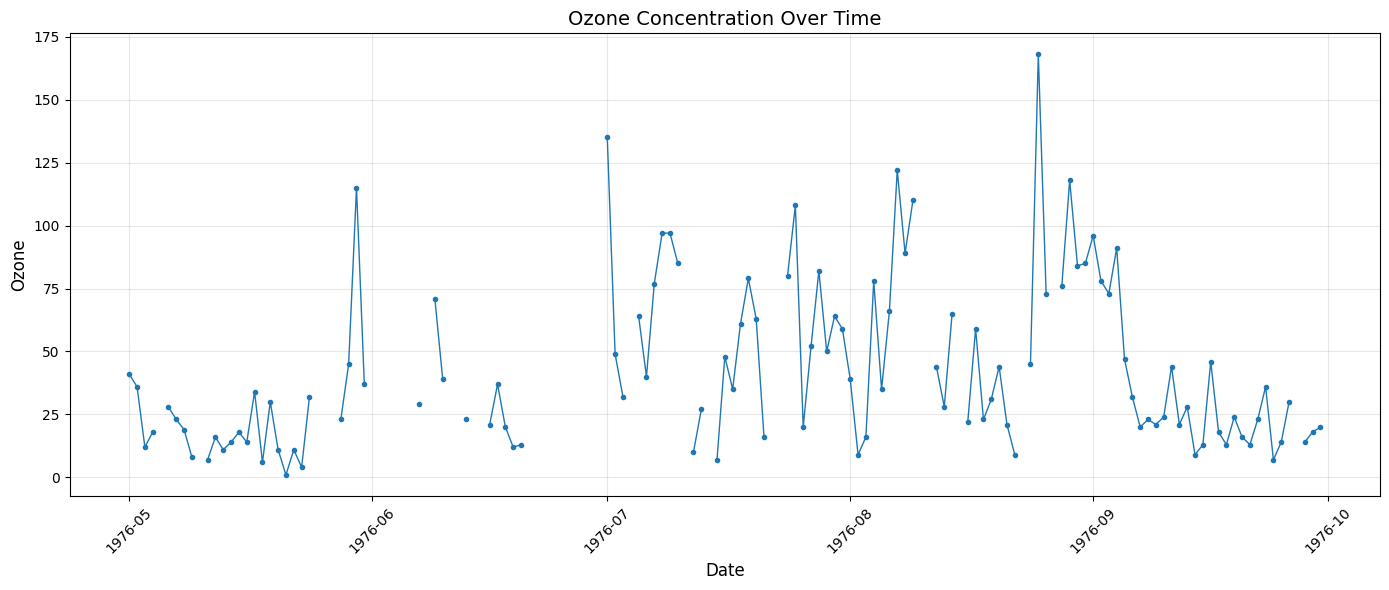

In [67]:
plt.figure(figsize=(14, 6))
plt.plot(air_quality['Date'], air_quality['Ozone'], marker='o', markersize=3, linestyle='-', linewidth=1)
plt.title('Ozone Concentration Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Ozone', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Imputation

So I have missing values, now what?

Fill in data but keep the relationship

<Axes: >

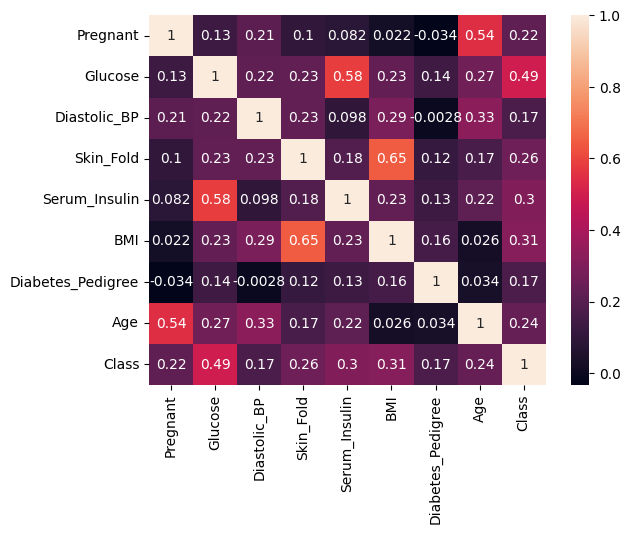

In [68]:
sns.heatmap(diabetes.corr(), annot=True)

<Axes: xlabel='Serum_Insulin', ylabel='Glucose'>

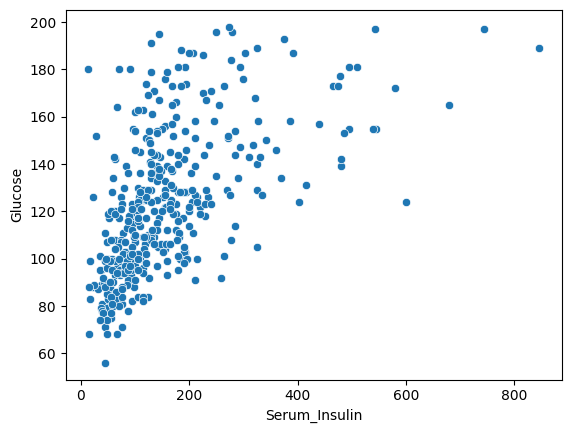

In [69]:
sns.scatterplot(data=diabetes, x='Serum_Insulin', y='Glucose')

Here are four different methods for Imputation
What happens in production?

In [70]:
from sklearn.experimental import enable_iterative_imputer

In [71]:
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

diabetes_mean = diabetes.copy(deep=True)
diabetes_median = diabetes.copy(deep=True)

diabetes_KNN = diabetes.copy(deep=True)
diabetes_MLR = diabetes.copy(deep=True)

mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')
KNN_imputer = KNNImputer()
MLR_imputer = IterativeImputer()

diabetes_mean.iloc[:,:] = mean_imputer.fit_transform(diabetes_mean)
diabetes_median.iloc[:,:] = median_imputer.fit_transform(diabetes_median)
diabetes_KNN.iloc[:,:] = KNN_imputer.fit_transform(diabetes_KNN)
diabetes_MLR.iloc[:,:] = MLR_imputer.fit_transform(diabetes_MLR)

<Axes: >

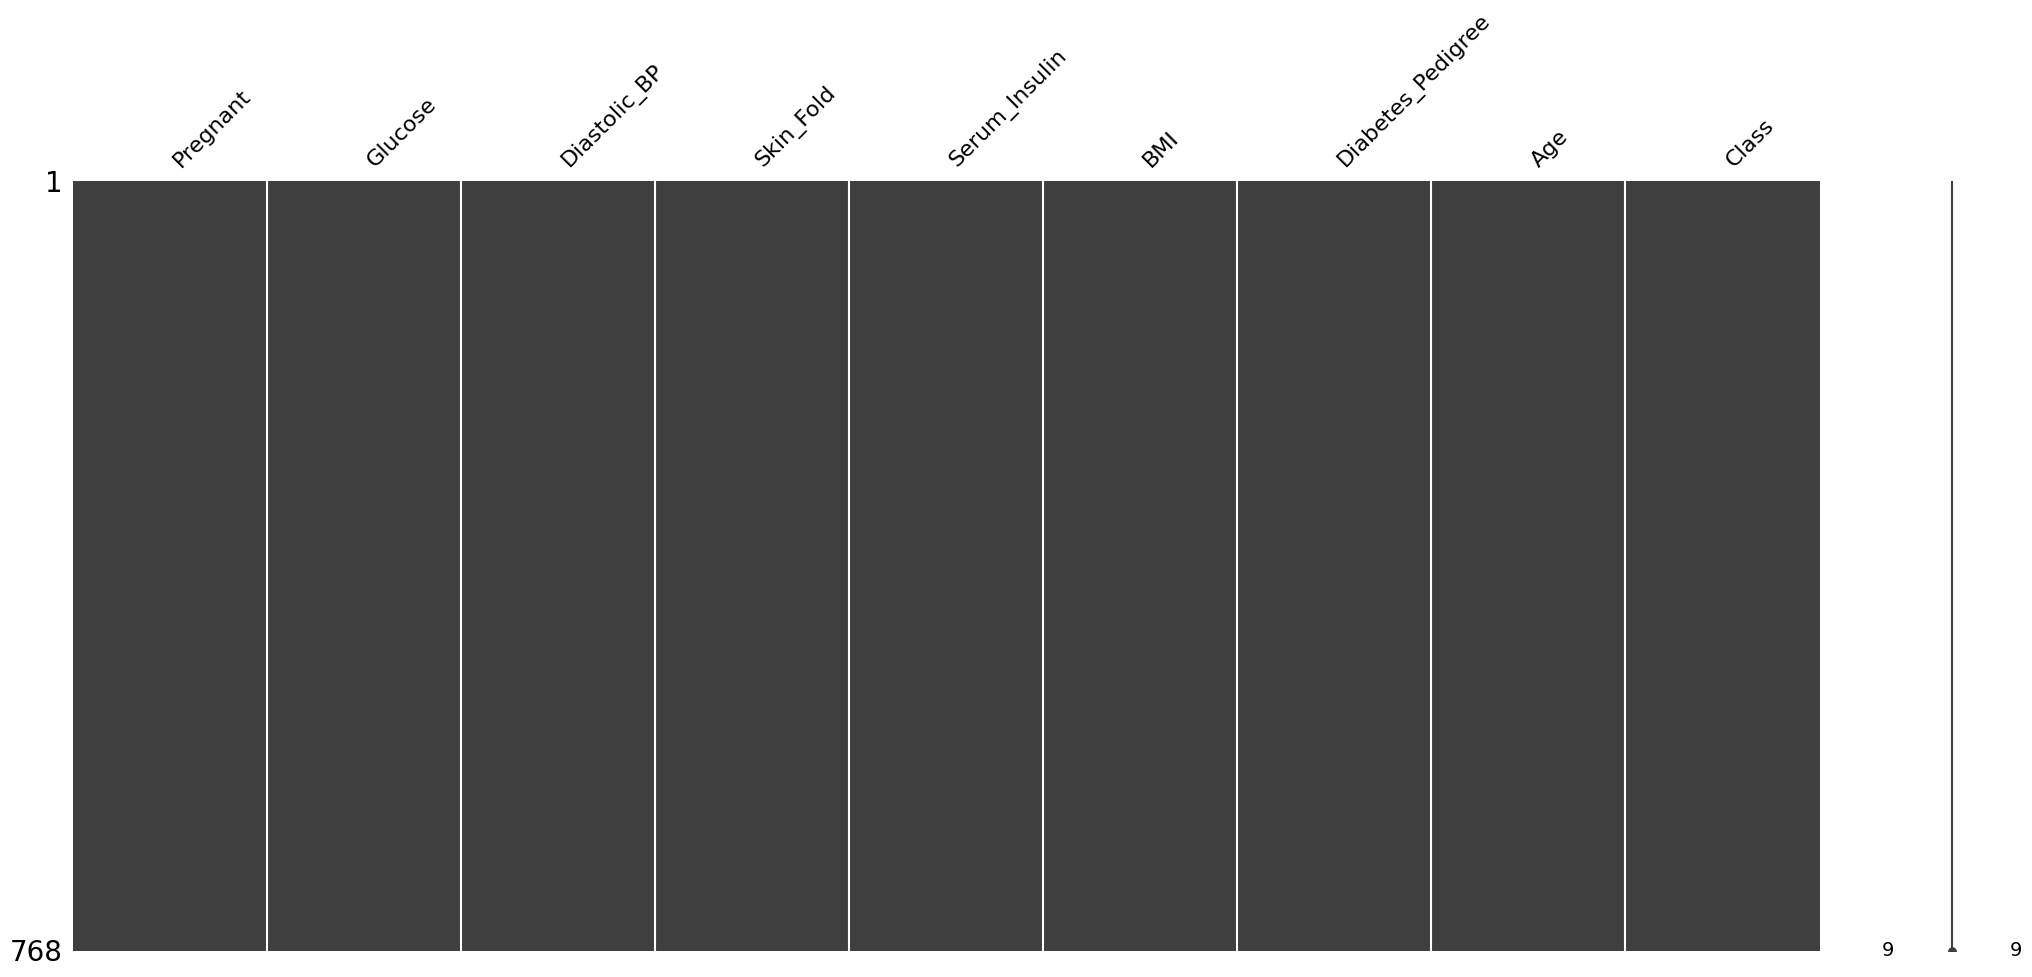

In [72]:
msno.matrix(diabetes_mean)

## Which imputed the best?

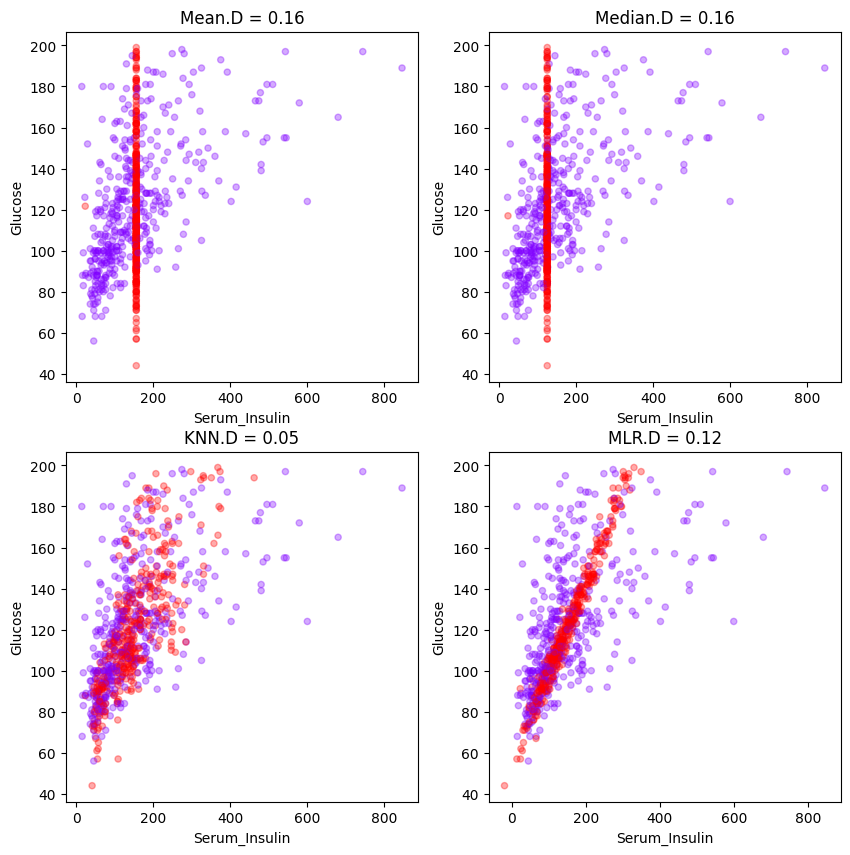

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
nulls = diabetes['Serum_Insulin'].isnull() + diabetes['Glucose'].isnull()

imputation_methods = {'Mean':diabetes_mean, 'Median':diabetes_median, 'KNN':diabetes_KNN, 'MLR':diabetes_MLR}
original_corr = 0.58
for method, axis in zip(imputation_methods, axes.flatten()):
    new_correlation = imputation_methods[method]['Serum_Insulin'].corr(imputation_methods[method]['Glucose'])
    distortion = round(np.abs(original_corr-new_correlation), 2)

    imputation_methods[method].plot(kind='scatter', x='Serum_Insulin', y='Glucose', c=nulls, cmap='rainbow', colorbar=False, title=f'{method}.D = {distortion}', alpha=1/3, ax=axis)

Always use KNN?

In [74]:
diabetes_clean = diabetes_KNN

House price prediction.

In [75]:
import pandas as pd
import re
import os

In [76]:
# os.chdir('/\\')

In [77]:
from utils.utils import setup_project_root
setup_project_root()

WindowsPath('C:/Users/zak/Projects/PyCharmProjects/data-science')

In [78]:
jp_bonds = pd.read_excel('data/bonds.xls')

In [79]:
jp_bonds

,最近5年間の国債及び借入金並びに政府保証債務現在高の推移\nCentral Government Debt\n(End of June 2020 - present),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,（単位：億円）\n（Unit: 100 million yen）,NaN,NaN
1,区 分\nCategory,NaN,NaN,R2.6末\n2020 June,R2.9末\n2020 September,R2.12末\n2020 December,R3.3末\n2021 March,R3.6末\n2021 June,R3.9末\n2021 September,R3.12末\n2021 December,...,R4.12末\n2022 December,R5.3末\n2023 March,R5.6末\n2023 June,R5.9末\n2023 September,R5.12末\n2023 December,R6.3末\n2024 March,R6.6末\n2024 June,R6.9末\n2024 September,R6.12末\n2024 December,R7.3末\n2025 March
2,内 国 債\n Government Bonds (JGBs),NaN,NaN,9911207,10048140,10406729,10741596,10667809,10581908,10886083,...,11154884,11363830,11340985,11312492,11460589,11571009,11601357,11659798,11735559,11828849
3,NaN,普 通 国 債\n General Bonds,NaN,8878351,8944094,9204312,9466468,9420071,9398435,9681121,...,10057772,10270973,10266311,10274129,10437786,10536526,10595603,10653140,10710047,10797344
4,NaN,NaN,（うち 復 興 債）\n（Reconstruction Bonds）,62251,64768,64687,67845,65684,61835,71745,...,48253,51792,50547,50547,40572,48757,48757,48757,48757,45544
5,NaN,NaN,（うち G X 経 済 移 行 債）\n（GX Economy Transition Bon...,ー,ー,ー,ー,ー,ー,ー,...,ー,ー,ー,ー,ー,24478,27974,31470,34970,37028
6,NaN,NaN,長期国債（10年以上）\n Long-term (10 years or more),7022591,7053084,7082554,7147462,7232492,7325507,7374212,...,7703876,7782665,7859214,7936770,8024061,8084264,8170289,8232295,8276876,8344266
7,NaN,NaN,中期国債（2年から5年）\n Medium-term (from 2 to 5 years),1595829,1580080,1553806,1591980,1648921,1667912,1694897,...,1825920,1835332,1869100,1917363,1928729,1945267,1972318,1998849,2023092,2027999
8,NaN,NaN,短期国債（1年以下）\n Short-term (one year or less),259931,310930,567952,727026,538658,405016,612013,...,527977,652976,537997,419997,484996,506996,452996,421996,410079,425079
9,NaN,財政投融資特別会計国債\n Fiscal Investment and Loan Progr...,NaN,938987,1010649,1109910,1186450,1156239,1093507,1115693,...,1009867,1008361,982841,945984,932846,945989,908151,910959,926854,914069


In [80]:
# jp_bonds
# numerical_cols = jp_bonds.columns[3:]
#
# for col in numerical_cols:
#     jp_bonds[col] = jp_bonds.transform(lambda row: None  )

## Language

In [81]:
def latinise(row):
    if type(row) != str:
        return row

    english_chr = re.findall(r'[A-Za-z]+', row)
    date_col = re.findall(r'\d{4}\s[A-Za-z]+', row)

    if date_col:
        return ' '.join(date_col)
    if english_chr:
        return ' '.join(english_chr)

In [82]:
for col in jp_bonds:
    jp_bonds[col] = jp_bonds[col].transform(latinise)

jp_bonds

,最近5年間の国債及び借入金並びに政府保証債務現在高の推移\nCentral Government Debt\n(End of June 2020 - present),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unit million yen,NaN,NaN
1,Category,NaN,NaN,2020 June,2020 September,2020 December,2021 March,2021 June,2021 September,2021 December,...,2022 December,2023 March,2023 June,2023 September,2023 December,2024 March,2024 June,2024 September,2024 December,2025 March
2,Government Bonds JGBs,NaN,NaN,9911207,10048140,10406729,10741596,10667809,10581908,10886083,...,11154884,11363830,11340985,11312492,11460589,11571009,11601357,11659798,11735559,11828849
3,NaN,General Bonds,NaN,8878351,8944094,9204312,9466468,9420071,9398435,9681121,...,10057772,10270973,10266311,10274129,10437786,10536526,10595603,10653140,10710047,10797344
4,NaN,NaN,Reconstruction Bonds,62251,64768,64687,67845,65684,61835,71745,...,48253,51792,50547,50547,40572,48757,48757,48757,48757,45544
5,NaN,NaN,G X GX Economy Transition Bonds,None,None,None,None,None,None,None,...,None,None,None,None,None,24478,27974,31470,34970,37028
6,NaN,NaN,Long term years or more,7022591,7053084,7082554,7147462,7232492,7325507,7374212,...,7703876,7782665,7859214,7936770,8024061,8084264,8170289,8232295,8276876,8344266
7,NaN,NaN,Medium term from to years,1595829,1580080,1553806,1591980,1648921,1667912,1694897,...,1825920,1835332,1869100,1917363,1928729,1945267,1972318,1998849,2023092,2027999
8,NaN,NaN,Short term one year or less,259931,310930,567952,727026,538658,405016,612013,...,527977,652976,537997,419997,484996,506996,452996,421996,410079,425079
9,NaN,Fiscal Investment and Loan Program Bonds,NaN,938987,1010649,1109910,1186450,1156239,1093507,1115693,...,1009867,1008361,982841,945984,932846,945989,908151,910959,926854,914069


## Further Row Dropping

## Pivoting data
Using melt to convert wide tables into taller tables


## Imputer Notes

Defining an impter class to store my note on imputing and provide reusable visualisations when I need them.

In [ ]:
import plotly


class ImputerNotes():
    def __init__(self, name):
        self.name = name

    def check_for_missing_data(self, df: pd.DataFrame):



In [85]:

diabetes

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63,0.0
764,2.0,122.0,70.0,27.0,NaN,36.8,0.340,27,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30,0.0
766,1.0,126.0,60.0,NaN,NaN,30.1,0.349,47,1.0
